In [1]:
!pip install geemap earthengine-api scikit-learn matplotlib pandas --quiet
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.8 MB/s eta 0:00:00
Done!


In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

ee.Authenticate(auth_mode='notebook')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=Ggg9iy4AITEe1KH9wEzNC5mdED80hBuMKjLd4OZL5Rk&tc=skU3ELYuGGUNcT09m88HVZIzwtwHY7BHV-SduSAAXEg&cc=sYLdS0lU-B9yrJpkhqqvQ3x5HDypEpiD37OxTHt68Ws

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1Aci98E9wCFH73pB93YzVqx5NHYjH0xM9FFuqrscX5-nUKQ3N8Phuk5l2kU4

Successfully saved authorization token.


In [3]:
ee.Initialize(project='project-911-491616')

savar = ee.Geometry.Rectangle([90.15, 23.75, 90.40, 24.00])

collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-11-01', '2024-02-28')
    .filterBounds(savar)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

image = collection.median().clip(savar)
ndvi = image.normalizedDifference(['B8', 'B4']).rename('ndvi_mean')
b5 = image.select('B5').rename('red_edge')
b8 = image.select('B8').rename('nir')
stacked = ndvi.addBands(b5).addBands(b8)

print("Data loaded!")

Data loaded!


In [4]:
# Sample 500 patches — same as Week 4
sample = stacked.sample(
    region=savar,
    scale=100,
    numPixels=500,
    seed=42
)

rows = []
for feat in sample.getInfo()['features']:
    p = feat['properties']
    ndvi_val = p.get('ndvi_mean')
    re_val = p.get('red_edge')
    nir_val = p.get('nir')
    if all(v is not None for v in [ndvi_val, re_val, nir_val]):
        rows.append({
            'ndvi_mean': ndvi_val,
            'red_edge': re_val,
            'nir': nir_val,
            'label': 1 if ndvi_val >= 0.4 else 0
        })

df = pd.DataFrame(rows)

# Retrain Random Forest — takes 2 seconds
X = df[['ndvi_mean', 'red_edge', 'nir']]
y = df['label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

print(f"Model retrained on {len(df)} patches!")
print(f"Healthy: {sum(y==1)}  |  Stressed: {sum(y==0)}")

Model retrained on 500 patches!
Healthy: 333  |  Stressed: 167


In [6]:
# Now sample 2000 points across ALL of Savar
full_sample = stacked.sample(
    region=savar,
    scale=100,
    numPixels=2000,
    seed=99,
    geometries=True    # this tells GEE to include coordinates!
)

full_rows = []
for feat in full_sample.getInfo()['features']:
    p = feat['properties']
    geom = feat.get('geometry')
    if geom is None:
        continue
    coords = geom['coordinates']
    ndvi_val = p.get('ndvi_mean')
    re_val = p.get('red_edge')
    nir_val = p.get('nir')
    if all(v is not None for v in [ndvi_val, re_val, nir_val]):
        full_rows.append({
            'lon': coords[0],
            'lat': coords[1],
            'ndvi_mean': ndvi_val,
            'red_edge': re_val,
            'nir': nir_val
        })

grid_df = pd.DataFrame(full_rows)
print(f"Sampled {len(grid_df)} points across Savar!")

Sampled 2000 points across Savar!


In [7]:
# Ask the model to predict every single point
X_grid = grid_df[['ndvi_mean', 'red_edge', 'nir']]
grid_df['prediction'] = rf.predict(X_grid)

healthy_count = sum(grid_df['prediction'] == 1)
stressed_count = sum(grid_df['prediction'] == 0)

print(f"Healthy patches:  {healthy_count}")
print(f"Stressed patches: {stressed_count}")
print(f"Stress percentage: {stressed_count/len(grid_df)*100:.1f}%")

Healthy patches:  1325
Stressed patches: 675
Stress percentage: 33.8%


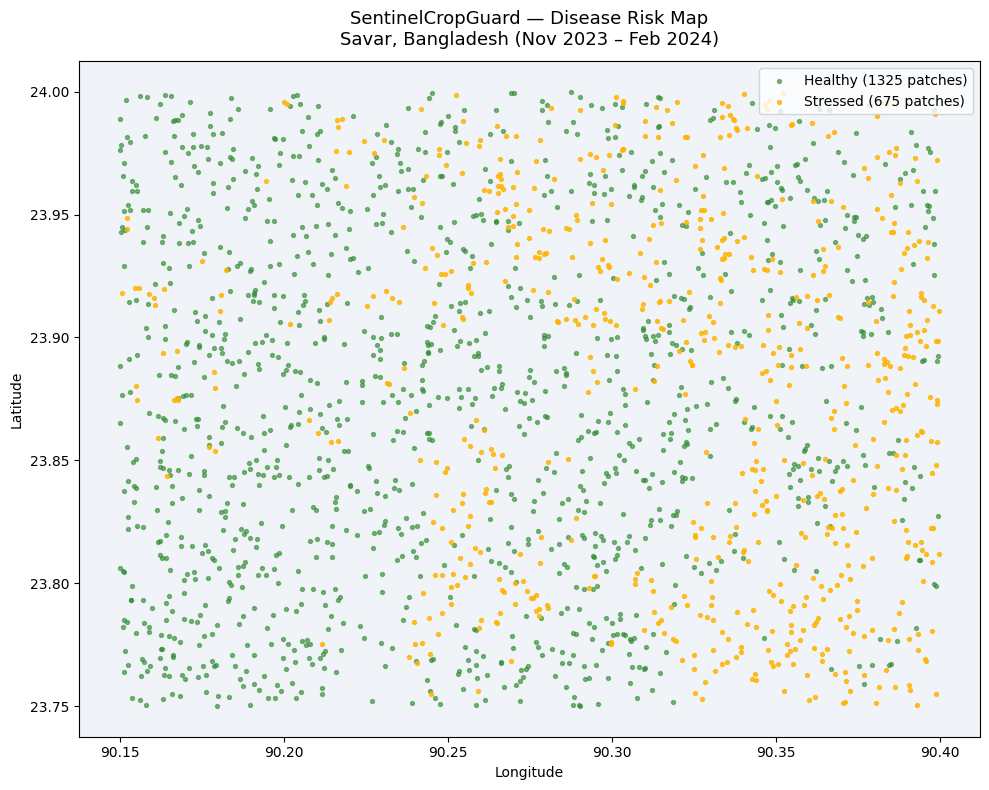

Risk map saved as risk_map.png!


In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

# Split into healthy and stressed
healthy = grid_df[grid_df['prediction'] == 1]
stressed = grid_df[grid_df['prediction'] == 0]

# Plot healthy = green, stressed = yellow
ax.scatter(healthy['lon'], healthy['lat'],
           c='#2d8a2d', s=8, alpha=0.6,
           label=f'Healthy ({len(healthy)} patches)')

ax.scatter(stressed['lon'], stressed['lat'],
           c='#FFB300', s=8, alpha=0.8,
           label=f'Stressed ({len(stressed)} patches)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SentinelCropGuard — Disease Risk Map\nSavar, Bangladesh (Nov 2023 – Feb 2024)',
             fontsize=13, pad=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_facecolor('#f0f4f8')
plt.tight_layout()
plt.savefig('risk_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("Risk map saved as risk_map.png!")

In [9]:
# Each pixel = 100m × 100m = 10,000 m² = 1 hectare exactly
# So each sampled point represents 1 hectare at scale=100

# Total area of Savar we sampled
total_area_ha = len(grid_df) * 1

# Stressed area
stressed_area_ha = stressed_count * 1

# Healthy area
healthy_area_ha = healthy_count * 1

print("=" * 45)
print("   SAVAR CROP STRESS AREA REPORT")
print("   Nov 2023 – Feb 2024")
print("=" * 45)
print(f"   Total area sampled:  {total_area_ha:,} hectares")
print(f"   Healthy area:        {healthy_area_ha:,} hectares")
print(f"   Stressed area:       {stressed_area_ha:,} hectares")
print(f"   Stress percentage:   {stressed_count/len(grid_df)*100:.1f}%")
print("=" * 45)

   SAVAR CROP STRESS AREA REPORT
   Nov 2023 – Feb 2024
   Total area sampled:  2,000 hectares
   Healthy area:        1,325 hectares
   Stressed area:       675 hectares
   Stress percentage:   33.8%


This week I applied the trained Random Forest model to 2000 new unseen patches across the entire Savar study area. Each patch was classified as healthy (green) or stressed (yellow) based on NDVI, red-edge, and NIR features. The resulting risk map shows healthy vegetation concentrated in the western agricultural zone and stress signals in the eastern urban zone — matching real geography. Affected stressed area was estimated in hectares using 100m scale sampling.